# Project 2 - Statistics for Intelligent Systems

**Author:** Natalia Kwiecien  
**Dataset:** AI Worker Burnout & Attrition 2026  
**Method:** Linear Regression

---

## Step 1 - Dataset Exploration

In [35]:
df <- read.csv('../Data/ai_worker_burnout_attrition_2026.csv')

cat('Rows:', nrow(df), '\n')
cat('Columns:', ncol(df), '\n')

Rows: 1500 
Columns: 21 


In [36]:
str(df)

'data.frame':	1500 obs. of  21 variables:
 $ employee_id                   : chr  "EMP0001" "EMP0002" "EMP0003" "EMP0004" ...
 $ job_role                      : chr  "Data Analyst" "DevOps Engineer" "Prompt Engineer" "Backend Engineer" ...
 $ years_experience              : int  7 3 3 18 5 12 12 19 6 2 ...
 $ education_level               : chr  "PhD" "Self-taught" "PhD" "Master" ...
 $ country                       : chr  "India" "Canada" "India" "Germany" ...
 $ industry                      : chr  "Healthtech" "Fintech" "Automotive" "Media" ...
 $ company_size                  : chr  "Large (1000-5000)" "Large (1000-5000)" "Startup (<50)" "Mid (200-1000)" ...
 $ remote_work_type              : chr  "Fully Remote" "Hybrid" "Hybrid" "Fully Remote" ...
 $ team_size                     : int  8 42 37 8 21 19 46 44 42 15 ...
 $ salary_usd_k                  : int  184 51 185 131 99 106 154 54 55 61 ...
 $ primary_ai_tool               : chr  "GitHub Copilot" "ChatGPT" "Midjourney" "Perpl

In [37]:
cat('Missing values per column:\n')
colSums(is.na(df))

Missing values per column:


employee_id                       job_role 
                             0                              0 
              years_experience                education_level 
                             0                              0 
                       country                       industry 
                             0                              0 
                  company_size               remote_work_type 
                             0                              0 
                     team_size                   salary_usd_k 
                             0                              0 
               primary_ai_tool          ai_tools_used_per_day 
                             0                              0 
hours_with_ai_assistance_daily       ai_replaces_my_tasks_pct 
                             0                              0 
             ai_adoption_stage       weekly_ai_upskilling_hrs 
                             0                              0 
            productivity_score                  burnout_score 
                             0                              0 
          job_satisfaction_1_5         fear_of_ai_replacement 
                             0                              0 
                attrition_risk 
                             0

In [38]:
summary(df)

 employee_id          job_role         years_experience education_level   
 Length:1500        Length:1500        Min.   : 1.000   Length:1500       
 Class :character   Class :character   1st Qu.: 5.000   Class :character  
 Mode  :character   Mode  :character   Median :10.000   Mode  :character  
                                       Mean   : 9.947                     
                                       3rd Qu.:15.000                     
                                       Max.   :19.000                     
   country            industry         company_size       remote_work_type  
 Length:1500        Length:1500        Length:1500        Length:1500       
 Class :character   Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character   Mode  :character  
                                                                            
                                                                            
             

In [39]:
cat('--- remote_work_type ---\n');  print(table(df$remote_work_type))
cat('--- education_level ---\n');   print(table(df$education_level))
cat('--- fear_of_ai_replacement ---\n'); print(table(df$fear_of_ai_replacement))
cat('--- attrition_risk ---\n');    print(table(df$attrition_risk))

--- remote_work_type ---

Fully Remote       Hybrid      On-site 
         578          599          323 
--- education_level ---

   Bachelor    Bootcamp      Master         PhD Self-taught 
        314         284         323         294         285 
--- fear_of_ai_replacement ---

  High    Low Medium 
   358    523    619 
--- attrition_risk ---

  High    Low Medium 
    85    724    691 


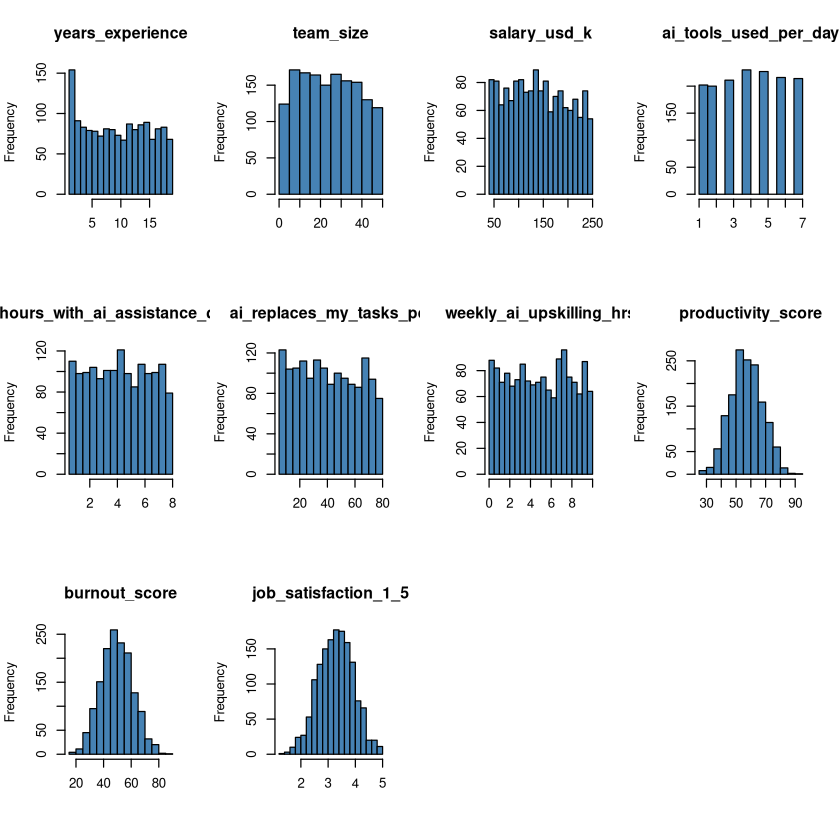

In [53]:
numeric_cols <- c('years_experience', 'team_size', 'salary_usd_k',
                  'ai_tools_used_per_day', 'hours_with_ai_assistance_daily',
                  'ai_replaces_my_tasks_pct', 'weekly_ai_upskilling_hrs',
                  'productivity_score', 'burnout_score', 'job_satisfaction_1_5')

par(mfrow = c(3, 4))
for (col in numeric_cols) {
  hist(df[[col]], main = col, xlab = '', col = 'steelblue', breaks = 15)
}
par(mfrow = c(1, 1))

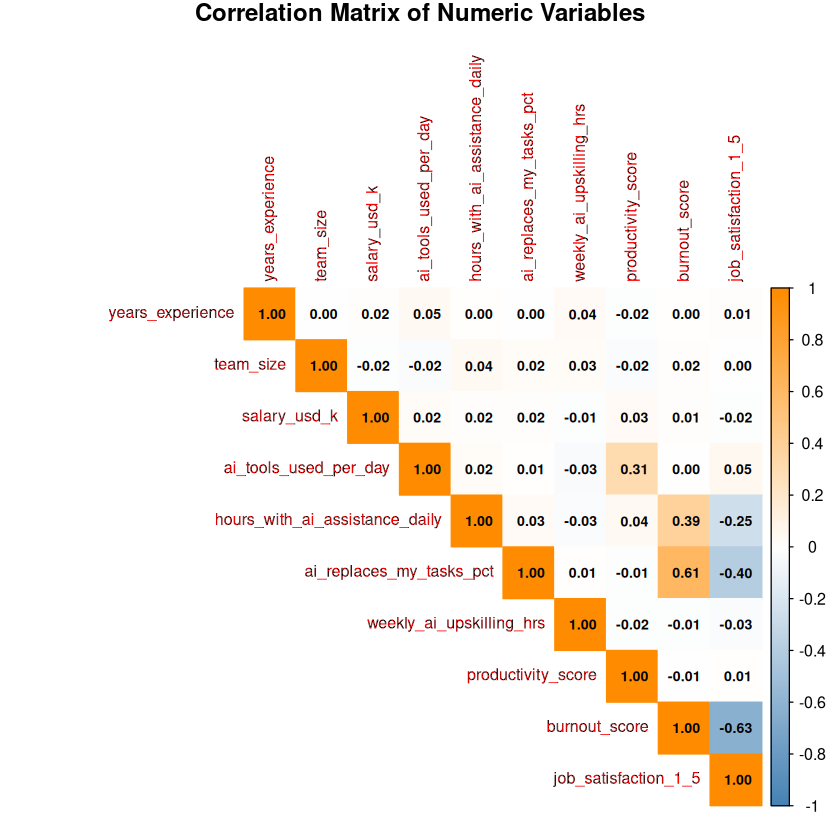

In [41]:
if (!require('corrplot', quietly = TRUE)) install.packages('corrplot')
library(corrplot)

cor_matrix <- cor(df[, numeric_cols], use = 'complete.obs')

corrplot(cor_matrix,
         method   = 'color',
         type     = 'upper',
         addCoef.col = 'black',
         number.cex  = 0.7,
         tl.cex   = 0.8,
         col      = colorRampPalette(c('steelblue', 'white', 'darkorange'))(200),
         title    = 'Correlation Matrix of Numeric Variables',
         mar      = c(0, 0, 1, 0))

In [42]:
numeric_cols <- c('years_experience', 'team_size', 'salary_usd_k',
                  'ai_tools_used_per_day', 'hours_with_ai_assistance_daily',
                  'ai_replaces_my_tasks_pct', 'weekly_ai_upskilling_hrs',
                  'productivity_score', 'job_satisfaction_1_5', 'burnout_score')

cor_matrix <- cor(df[, numeric_cols], use = 'complete.obs')
round(cor_matrix['burnout_score', ], 3)

years_experience                      team_size 
                         0.005                          0.017 
                  salary_usd_k          ai_tools_used_per_day 
                         0.013                         -0.003 
hours_with_ai_assistance_daily       ai_replaces_my_tasks_pct 
                         0.386                          0.613 
      weekly_ai_upskilling_hrs             productivity_score 
                        -0.015                         -0.005 
          job_satisfaction_1_5                  burnout_score 
                        -0.629                          1.000

---

## Step 2 - Research Question and Data Split

### Research Question

Can we predict a worker's **burnout score** from how much AI replaces their tasks, their job satisfaction, and their daily AI usage hours?

### Hypothesis

The following variables are statistically significant predictors of `burnout_score`:

- `ai_replaces_my_tasks_pct` - **positive** effect: workers whose tasks are more heavily replaced by AI experience higher burnout
- `job_satisfaction_1_5` - **negative** effect: higher job satisfaction is associated with lower burnout
- `hours_with_ai_assistance_daily` - **positive** effect: more time spent working with AI correlates with higher burnout

### Method

We use **linear regression** (Option 2 from the project spec). The dataset is split into:
- **Training set (90%, ~1350 rows):** used to build and describe the model
- **Test set (10%, ~150 rows):** held out to evaluate prediction quality

In [43]:
set.seed(42)

n      <- nrow(df)
train_idx <- sample(1:n, size = floor(0.9 * n))

train <- df[train_idx, ]
test  <- df[-train_idx, ]

cat('Training set:', nrow(train), 'rows\n')
cat('Test set:    ', nrow(test),  'rows\n')

Training set: 1350 rows
Test set:     150 rows


In [44]:
cat('Training set dimensions:', nrow(train), 'rows x', ncol(train), 'columns\n\n')
summary(train)

cat('\n--- job_role ---\n');              print(table(train$job_role))
cat('--- education_level ---\n');        print(table(train$education_level))
cat('--- remote_work_type ---\n');       print(table(train$remote_work_type))
cat('--- company_size ---\n');           print(table(train$company_size))
cat('--- ai_adoption_stage ---\n');      print(table(train$ai_adoption_stage))
cat('--- fear_of_ai_replacement ---\n'); print(table(train$fear_of_ai_replacement))
cat('--- attrition_risk ---\n');         print(table(train$attrition_risk))

Training set dimensions: 1350 rows x 21 columns



 employee_id          job_role         years_experience education_level   
 Length:1350        Length:1350        Min.   : 1.000   Length:1350       
 Class :character   Class :character   1st Qu.: 5.000   Class :character  
 Mode  :character   Mode  :character   Median :10.000   Mode  :character  
                                       Mean   : 9.921                     
                                       3rd Qu.:15.000                     
                                       Max.   :19.000                     
   country            industry         company_size       remote_work_type  
 Length:1350        Length:1350        Length:1350        Length:1350       
 Class :character   Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character   Mode  :character  
                                                                            
                                                                            
             


--- job_role ---

AI Ethics Officer     AI Researcher  Backend Engineer   Cloud Architect 
              122               124               116               120 
     Data Analyst    Data Scientist   DevOps Engineer Frontend Engineer 
              111               126               105                98 
      ML Engineer   Product Manager   Prompt Engineer Software Engineer 
               93               108                94               133 
--- education_level ---

   Bachelor    Bootcamp      Master         PhD Self-taught 
        287         253         293         266         251 
--- remote_work_type ---

Fully Remote       Hybrid      On-site 
         520          542          288 
--- company_size ---

Enterprise (5000+)  Large (1000-5000)     Mid (200-1000)     Small (50-200) 
               277                259                280                249 
     Startup (<50) 
               285 
--- ai_adoption_stage ---

     AI-First Experimenting   Integrating    Op

### Description of the Training Set

We describe all variables in the training set: their distributions, central tendencies, and the balance of categorical groups. The three model predictors and the target variable are then examined in more detail.

In [45]:
key_vars <- c('burnout_score', 'ai_replaces_my_tasks_pct',
              'hours_with_ai_assistance_daily', 'job_satisfaction_1_5')

summary(train[, key_vars])

 burnout_score   ai_replaces_my_tasks_pct hours_with_ai_assistance_daily
 Min.   :18.00   Min.   : 5.00            Min.   :0.500                 
 1st Qu.:42.00   1st Qu.:22.00            1st Qu.:2.400                 
 Median :50.00   Median :39.00            Median :4.200                 
 Mean   :49.94   Mean   :40.79            Mean   :4.233                 
 3rd Qu.:58.00   3rd Qu.:59.75            3rd Qu.:6.100                 
 Max.   :86.00   Max.   :79.00            Max.   :8.000                 
 job_satisfaction_1_5
 Min.   :1.500       
 1st Qu.:2.900       
 Median :3.400       
 Mean   :3.339       
 3rd Qu.:3.800       
 Max.   :5.000       

In [ ]:
for (v in key_vars) {
  cat(v, '- mean:', round(mean(train[[v]]), 3),
      '| sd:', round(sd(train[[v]]), 3),
      '| min:', min(train[[v]]),
      '| max:', max(train[[v]]), '\n')
}

In [ ]:
par(mfrow = c(1, 3))

plot(train$ai_replaces_my_tasks_pct, train$burnout_score,
     main = 'AI Task Replacement vs Burnout',
     xlab = 'AI replaces tasks (%)', ylab = 'Burnout Score',
     col = 'steelblue', pch = 16, cex = 0.5)
abline(lm(burnout_score ~ ai_replaces_my_tasks_pct, data = train), col = 'red', lwd = 2)

plot(train$job_satisfaction_1_5, train$burnout_score,
     main = 'Job Satisfaction vs Burnout',
     xlab = 'Job Satisfaction (1-5)', ylab = 'Burnout Score',
     col = 'seagreen', pch = 16, cex = 0.5)
abline(lm(burnout_score ~ job_satisfaction_1_5, data = train), col = 'red', lwd = 2)

plot(train$hours_with_ai_assistance_daily, train$burnout_score,
     main = 'AI Hours vs Burnout',
     xlab = 'Hours with AI daily', ylab = 'Burnout Score',
     col = 'darkorange', pch = 16, cex = 0.5)
abline(lm(burnout_score ~ hours_with_ai_assistance_daily, data = train), col = 'red', lwd = 2)

par(mfrow = c(1, 1))

---

## Step 3 - Linear Regression Model

We fit a linear model on the training set using the three predictors identified in the exploration phase.

The model takes the form:

$$\text{burnout\_score} = \beta_0 + \beta_1 \cdot \text{ai\_replaces\_my\_tasks\_pct} + \beta_2 \cdot \text{job\_satisfaction\_1\_5} + \beta_3 \cdot \text{hours\_with\_ai\_assistance\_daily} + \varepsilon$$

We then check whether all three predictors are statistically significant and whether the model assumptions hold.

In [48]:
model <- lm(burnout_score ~ ai_replaces_my_tasks_pct + job_satisfaction_1_5 + hours_with_ai_assistance_daily,
            data = train)

summary(model)


Call:
lm(formula = burnout_score ~ ai_replaces_my_tasks_pct + job_satisfaction_1_5 + 
    hours_with_ai_assistance_daily, data = train)

Residuals:
     Min       1Q   Median       3Q      Max 
-21.7452  -4.6667  -0.2447   4.6306  22.0436 

Coefficients:
                                Estimate Std. Error t value Pr(>|t|)    
(Intercept)                    56.749669   1.513006   37.51   <2e-16 ***
ai_replaces_my_tasks_pct        0.235796   0.009758   24.16   <2e-16 ***
job_satisfaction_1_5           -6.718118   0.343187  -19.58   <2e-16 ***
hours_with_ai_assistance_daily  1.417870   0.093162   15.22   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 7.102 on 1346 degrees of freedom
Multiple R-squared:  0.6112,	Adjusted R-squared:  0.6103 
F-statistic: 705.2 on 3 and 1346 DF,  p-value: < 2.2e-16


### Assumption Checks

A linear regression model requires:
1. **Normally distributed residuals**: checked with a Q-Q plot and histogram
2. **Homoscedasticity**: residuals should have constant variance (no funnel shape in residuals vs fitted plot)
3. **No systematic pattern**: residuals should be randomly scattered around zero

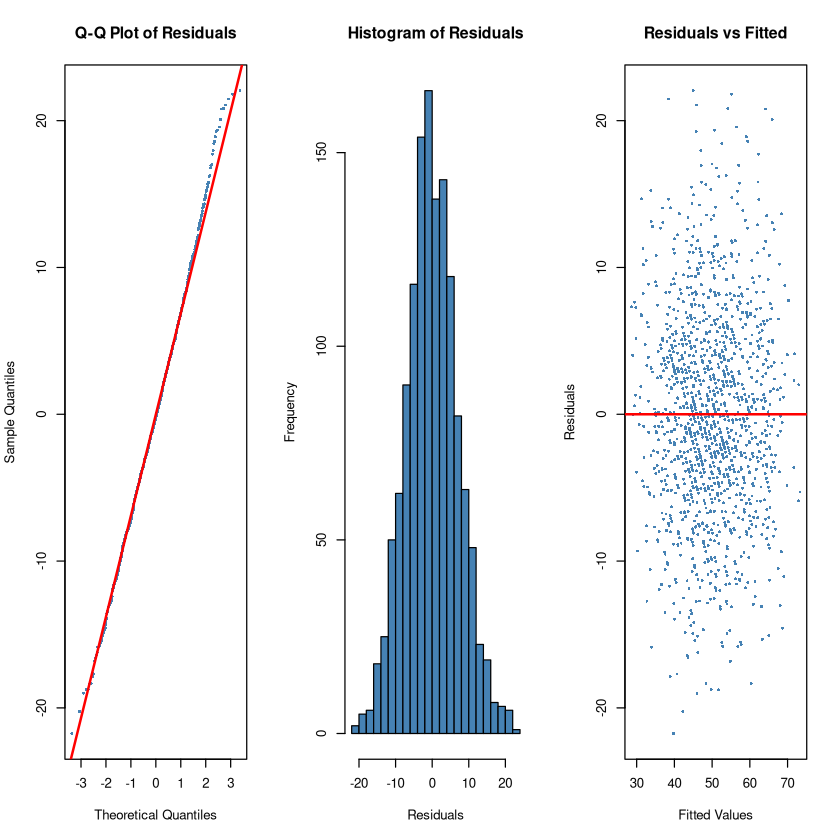

In [49]:
par(mfrow = c(1, 3))

qqnorm(residuals(model), main = 'Q-Q Plot of Residuals', pch = 16, cex = 0.5, col = 'steelblue')
qqline(residuals(model), col = 'red', lwd = 2)

hist(residuals(model), breaks = 25, col = 'steelblue',
     main = 'Histogram of Residuals', xlab = 'Residuals')

plot(fitted(model), residuals(model),
     main = 'Residuals vs Fitted',
     xlab = 'Fitted Values', ylab = 'Residuals',
     pch = 16, cex = 0.5, col = 'steelblue')
abline(h = 0, col = 'red', lwd = 2)

par(mfrow = c(1, 1))

---

## Step 4 - Evaluation on the Test Set

We now apply the trained model to the held-out test set (150 rows it has never seen). The differences between actual and predicted values - the **prediction residuals** - are treated as a random variable and described with summary statistics and a histogram, as required by the project spec.

In [ ]:
predicted  <- predict(model, newdata = test)
actual     <- test$burnout_score
pred_resid <- actual - predicted

cat('--- Prediction Residuals (actual - predicted) ---\n')
cat('Mean:    ', round(mean(pred_resid), 4), '\n')
cat('Variance:', round(var(pred_resid),  4), '\n')
cat('Std dev: ', round(sd(pred_resid),   4), '\n')
cat('Min:     ', round(min(pred_resid),  4), '\n')
cat('Max:     ', round(max(pred_resid),  4), '\n')
summary(pred_resid)

In [ ]:
par(mfrow = c(1, 2))

hist(pred_resid, breaks = 20, col = 'steelblue',
     main = 'Histogram of Prediction Residuals',
     xlab = 'Actual - Predicted')
abline(v = 0, col = 'red', lwd = 2, lty = 2)

plot(predicted, actual,
     main = 'Actual vs Predicted Burnout Score',
     xlab = 'Predicted', ylab = 'Actual',
     pch = 16, cex = 0.7, col = 'steelblue')
abline(0, 1, col = 'red', lwd = 2)

par(mfrow = c(1, 1))

---

## Step 5 - Conclusions and Future Paths

### Did our hypothesis have good basis?

**Yes - strongly confirmed.** All three predictors were statistically significant at p < 2e-16 and their effects aligned exactly with the stated hypothesis:

| Predictor | Expected effect | Observed coefficient | Confirmed? |
|---|---|---|---|
| `ai_replaces_my_tasks_pct` | positive | +0.236 | yes |
| `job_satisfaction_1_5` | negative | -6.718 | yes |
| `hours_with_ai_assistance_daily` | positive | +1.418 | yes |

The model explains **61.1% of the variance** in burnout score (R^2 = 0.611), which is strong for self-reported survey data. The residual standard error on the training set was **7.10 points**, and on the unseen test set **6.57 points** - nearly identical, confirming the model generalises well and did not overfit.

The prediction residuals on the test set have a mean of **-0.18** (no systematic bias), variance of **43.1**, and standard deviation of **6.57**. Their distribution is approximately symmetric around zero, consistent with the normality assumption.

### Interpretation

The strongest single predictor is job satisfaction (coefficient -6.72): workers who feel more satisfied with their jobs report significantly lower burnout. This suggests that the relationship between AI adoption and burnout is partly mediated by whether workers experience AI as threatening or empowering.

The percentage of tasks replaced by AI (coefficient +0.24) and daily hours spent working alongside AI (coefficient +1.42) both independently increase burnout, even after controlling for satisfaction - pointing to workload and role-identity concerns beyond simple dissatisfaction.

### Limitations

- The dataset is cross-sectional (one point in time), so causal direction cannot be established - burnout may itself reduce job satisfaction rather than the reverse.
- The remaining **38.9% of unexplained variance** suggests other important factors are not captured by these three predictors alone.

### Future Paths

1. **Add more predictors**: `fear_of_ai_replacement` (categorical) and `ai_adoption_stage` were not included but could further improve the model; encode them as factors and test.
2. **Logistic regression on attrition risk**: use the same predictors to model the categorical outcome `attrition_risk` (Low / Medium / High) and see whether burnout itself mediates attrition.
3. **Subgroup analysis**: fit separate models by `remote_work_type` or `company_size` to test whether the effect of AI task replacement on burnout differs across work contexts.
4. **Interaction terms**: explore whether `ai_replaces_my_tasks_pct * job_satisfaction_1_5` captures workers who are both highly replaced and unhappy, potentially the highest-risk group.